--- 1. Otomotiv Servis Verileri Yükleniyor ---
Toplam Kayıt Sayısı: 7

--- 2. Veri Temizleme: Hatalı Kayıtlar Ayıklanıyor ---
Analize Hazır Kayıt Sayısı: 5

--- 3. Müşteri Segmentasyon Algoritması Çalıştırılıyor ---
--- 4. Stratejik Görsel Rapor Oluşturuluyor ---
İşlem Başarıyla Tamamlandı: Veri, Analiz ve Görsel Uyumlu!


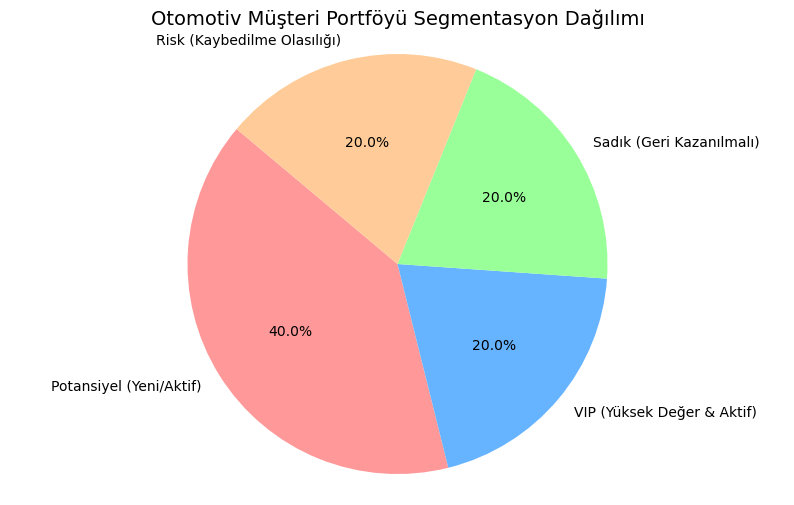

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# =================================================================
# GÜN 6: OTOMOTİV SEKTÖRÜ MÜŞTERİ SEGMENTASYONU VE ANALİZİ
# =================================================================

# 1. Simüle Edilmiş Otomotiv Servis Verisi (Kirli Veri)
raw_data = """musteri_id,ad,toplam_servis_harcamasi,son_servis_tarihi,arac_segmenti
101,Ali,1500,2023-10-01,B-SUV
102,Ayse,4500,2023-10-03,C-Sedan
103,Mehmet,-200,2023-09-01,Hatchback
104,Zeynep,NaN,2023-10-05,C-Sedan
105,Can,2200,2023-08-15,D-Sedan
106,Derya,800,2023-10-04,B-SUV
107,Burak,50,2023-05-01,Hatchback
"""

print("--- 1. Otomotiv Servis Verileri Yükleniyor ---")
df = pd.read_csv(io.StringIO(raw_data))
print(f"Toplam Kayıt Sayısı: {len(df)}\n")

# =================================================================
# 2. VERİ TEMİZLEME (DATA CLEANING)
# =================================================================
print("--- 2. Veri Temizleme: Hatalı Kayıtlar Ayıklanıyor ---")

df['son_servis_tarihi'] = pd.to_datetime(df['son_servis_tarihi'])

# Harcaması olmayan (NaN) veya hatalı (negatif) kayıtları temizle
temiz_df = df.dropna(subset=['toplam_servis_harcamasi']).copy()
temiz_df = temiz_df[temiz_df['toplam_servis_harcamasi'] > 0]

# Recency: Son servisten bu yana geçen gün
bugun = pd.to_datetime("2023-10-10")
temiz_df['pasif_gun_sayisi'] = (bugun - temiz_df['son_servis_tarihi']).dt.days

print(f"Analize Hazır Kayıt Sayısı: {len(temiz_df)}\n")

# =================================================================
# 3. ANALİTİK SEGMENTASYON (OTOMOTİV ODAKLI RFM)
# =================================================================
print("--- 3. Müşteri Segmentasyon Algoritması Çalıştırılıyor ---")

def otomotiv_segment_olustur(row):
    harcama = row['toplam_servis_harcamasi']
    pasiflik = row['pasif_gun_sayisi']
    
    if harcama > 2000 and pasiflik < 30:
        return "VIP (Yüksek Değer & Aktif)"
    elif harcama > 2000 and pasiflik >= 30:
        return "Sadık (Geri Kazanılmalı)"
    elif harcama <= 2000 and pasiflik < 15:
        return "Potansiyel (Yeni/Aktif)"
    else:
        return "Risk (Kaybedilme Olasılığı)"

temiz_df['Segment'] = temiz_df.apply(otomotiv_segment_olustur, axis=1)

# =================================================================
# 4. GÖRSELLEŞTİRME VE STRATEJİK RAPORLAMA
# =================================================================
print("--- 4. Stratejik Görsel Rapor Oluşturuluyor ---")

segment_counts = temiz_df['Segment'].value_counts()

plt.figure(figsize=(10, 6))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Otomotiv Müşteri Portföyü Segmentasyon Dağılımı', fontsize=14)
plt.axis('equal')

plt.savefig("otomotiv_segmentasyon_analizi.png")
temiz_df.to_csv("otomotiv_stratejik_analiz_raporu.csv", index=False)

print("İşlem Başarıyla Tamamlandı: Veri, Analiz ve Görsel Uyumlu!")